# **Validación de resultados**

## 1. Definición de rutas

In [2]:
from pathlib import Path

import polars as pl

ROOT = Path.cwd()
OUT_DIR = ROOT / "data" / "output"
if not OUT_DIR.exists():
    OUT_DIR = ROOT.parent / "data" / "output"

parquet_path = OUT_DIR / "forecast_seccion_1_partial.parquet"
if not parquet_path.exists():
    raise FileNotFoundError(f"Parquet file not found: {parquet_path}")

df = pl.read_parquet(parquet_path)

## 2. Función graficadora

In [3]:
import matplotlib.pyplot as plt


def graph_plot(filtered: pl.DataFrame, unique_id: str):
    x = filtered["ds"].to_list()
    y_value = filtered["value"].to_list()
    y_valuehat = filtered["valuehat"].to_list()

    plt.figure(figsize=(12, 5))
    plt.plot(x, y_value, label="value", linewidth=1)
    plt.plot(x, y_valuehat, label="valuehat", linewidth=1)
    plt.xlabel("ds")
    plt.ylabel("series")
    plt.title(f"Series value y valuehat para UNIQUE_ID={unique_id}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3. Resultados Sección 1

shape: (5, 3)
┌────────────┬───────────┬───────────┐
│ ds         ┆ value     ┆ valuehat  │
│ ---        ┆ ---       ┆ ---       │
│ date       ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╡
│ 2024-05-26 ┆ 407461.33 ┆ 367298.31 │
│ 2024-05-27 ┆ 416580.47 ┆ 361018.71 │
│ 2024-05-28 ┆ 424067.29 ┆ 428660.72 │
│ 2024-05-29 ┆ 361591.23 ┆ 336306.3  │
│ 2024-05-30 ┆ 316492.79 ┆ 318273.41 │
└────────────┴───────────┴───────────┘


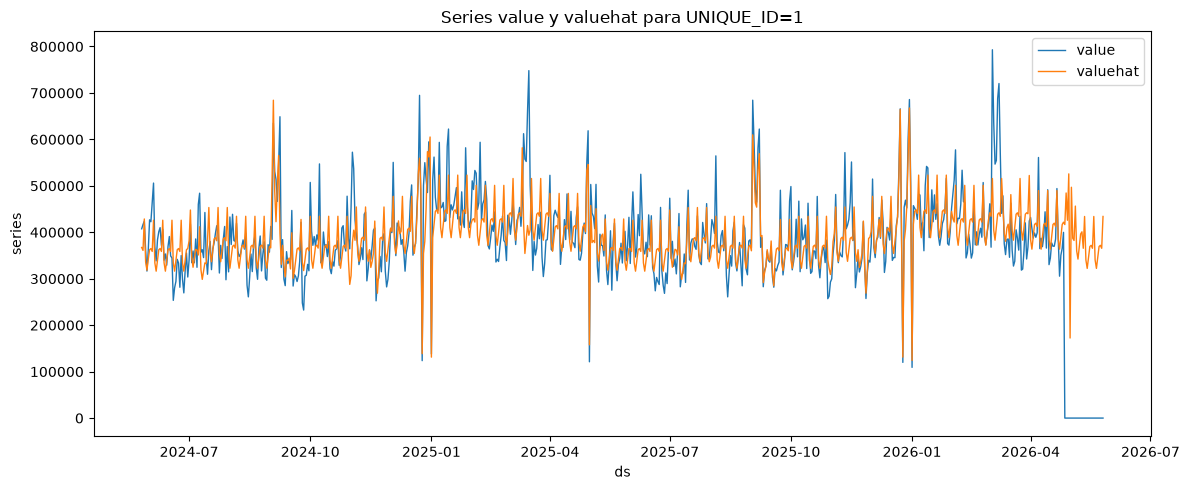

In [4]:
filtered = (
    df.filter(pl.col("unique_id") == "1").select(["ds", "value", "valuehat"]).sort("ds")
)

print(filtered.head())

graph_plot(filtered, "1")


## 4. Resultados Tienda 00063

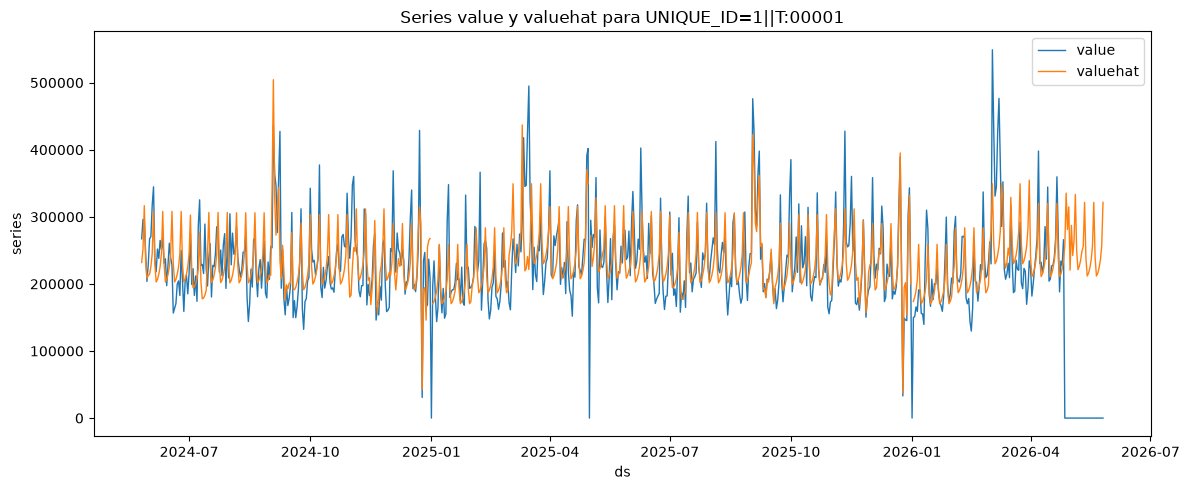

In [5]:
unique_id = "1||T:00001"

filtered = (
    df.filter(pl.col("unique_id") == unique_id)
    .select(["ds", "value", "valuehat"])
    .sort("ds")
)

graph_plot(filtered, unique_id)

## 5. Selección de SKU

In [6]:
import polars as pl

unique_id = "T:00001||S:"

qry = (
    df.filter(pl.col("unique_id").str.contains(unique_id, literal=True))
    .select(["unique_id", "ds", "value", "valuehat"])
    .with_columns((pl.col("valuehat") / pl.col("value")).alias("ratio"))
    .filter(pl.col("ratio").is_between(0.8, 1.2, closed="none"))
    .sort("ds")
)

qry

unique_id,ds,value,valuehat,ratio
str,date,f64,f64,f64
"""1||T:00001||S:100622""",2024-05-26,1167.99,1167.99,1.0
"""1||T:00001||S:106356""",2024-05-26,12252.23,12252.23,1.0
"""1||T:00001||S:116741""",2024-05-26,9960.52,9960.52,1.0
"""1||T:00001||S:127359""",2024-05-26,9474.53,9474.53,1.0
"""1||T:00001||S:143871""",2024-05-26,11241.42,11241.42,1.0
…,…,…,…,…
"""1||T:00001||S:565871""",2026-04-26,2561.99,2918.98,1.139341
"""1||T:00001||S:580661""",2026-04-26,7583.61,8067.96,1.063868
"""1||T:00001||S:58905""",2026-04-26,8939.4,7776.62,0.869926


## 6. Probemos con 1||T:00211||S:495934

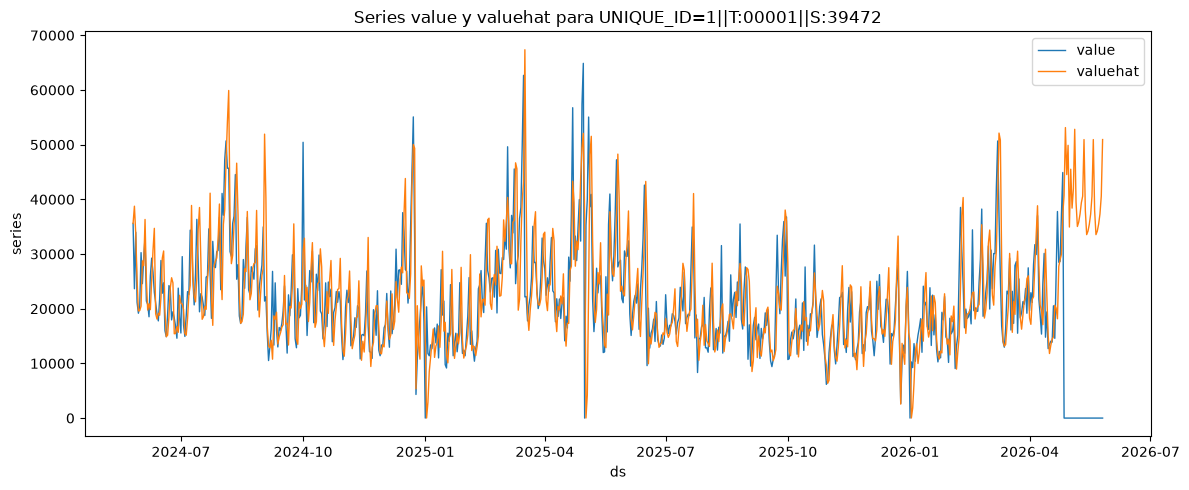

In [8]:
unique_id = "1||T:00001||S:39472"

filtered = (
    df.filter(pl.col("unique_id") == unique_id)
    # .select(["ds", "value", "valuehat"])
    .sort("ds")
)

filtered.write_parquet(OUT_DIR / f"forecast_{'1__T_00001__S_39472'}.parquet")

graph_plot(filtered, unique_id)

In [ ]:
wmape_path = OUT_DIR / "wmape.parquet"

df_wmape = pl.read_parquet(wmape_path)
df_wmape.filter(
    (pl.col("wmape") != 0) & pl.col("unique_id").str.starts_with("1||")
).sort("wmape", descending=False)

In [ ]:
df.filter(
    (pl.col("unique_id") == "1||T:00063") & (pl.col("period_type") == "forecast_only")
).sort("ds")